In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

pd.set_option('display.max_columns', None)

df = pd.read_excel('../data/ApexPlanet_DataAnalytics_Dataset.xlsx')

df.head()

,Order_ID,Order_Date,Customer_ID,Customer_Name,Age,Gender,City,Product,Category,Quantity,Unit_Price,Total_Sales
0,ORD100002,2025-02-25,CUST5529,Customer_227,30.0,Female,Bengaluru,Rice,Grocery,7,2829.77,19808.39
1,ORD100003,2025-10-14,CUST3127,Customer_182,63.0,Male,Bengaluru,Book,Education,5,27906.16,139530.80
2,ORD100004,2025-05-13,CUST8887,Customer_487,62.0,Female,Bengaluru,Book,Education,8,37491.06,299928.48
3,ORD100005,2025-12-02,CUST2515,Customer_470,65.0,Female,Kolkata,Mobile,Electronics,9,28541.36,256872.24
4,ORD100006,2025-11-20,CUST4796,Customer_380,44.0,Male,Bengaluru,Rice,Grocery,10,14036.59,140365.90


In [3]:
print("Shape:", df.shape)

print("\nColumns:\n")

print(df.columns)

print("\nDataset Information:\n")

df.info()

Shape: (1000, 12)

Columns:

Index(['Order_ID', 'Order_Date', 'Customer_ID', 'Customer_Name', 'Age',
       'Gender', 'City', 'Product', 'Category', 'Quantity', 'Unit_Price',
       'Total_Sales'],
      dtype='str')

Dataset Information:

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Order_ID       1000 non-null   str    
 1   Order_Date     1000 non-null   str    
 2   Customer_ID    1000 non-null   str    
 3   Customer_Name  1000 non-null   str    
 4   Age            980 non-null    float64
 5   Gender         1000 non-null   str    
 6   City           987 non-null    str    
 7   Product        1000 non-null   str    
 8   Category       1000 non-null   str    
 9   Quantity       1000 non-null   int64  
 10  Unit_Price     1000 non-null   float64
 11  Total_Sales    1000 non-null   float64
dtypes: float64(3), int64(1), str(8)
memory usage

In [4]:
total_revenue = df['Total_Sales'].sum()

total_orders = df['Order_ID'].nunique()

total_customers = df['Customer_ID'].nunique()

average_order_value = df['Total_Sales'].mean()

revenue_per_customer = total_revenue / total_customers

average_quantity_per_order = df['Quantity'].sum() / total_orders

print("Total Revenue:", round(total_revenue,2))

print("Total Orders:", total_orders)

print("Total Customers:", total_customers)

print("Average Order Value:", round(average_order_value,2))

print("Revenue Per Customer:", round(revenue_per_customer,2))

print("Average Quantity Per Order:", round(average_quantity_per_order,2))

Total Revenue: 139399439.65
Total Orders: 992
Total Customers: 947
Average Order Value: 139399.44
Revenue Per Customer: 147201.1
Average Quantity Per Order: 5.48


In [5]:
customer_df = df.groupby('Customer_ID').agg({
    'Total_Sales':'sum',
    'Quantity':'sum',
    'Age':'mean'
}).reset_index()

customer_df.head()

,Customer_ID,Total_Sales,Quantity,Age
0,CUST1004,8321.54,2,64.0
1,CUST1017,264230.68,7,42.0
2,CUST1026,164965.29,7,65.0
3,CUST1032,146990.90,7,22.0
4,CUST1038,37068.40,5,32.0


In [6]:
customer_df.isnull().sum()

Customer_ID     0
Total_Sales     0
Quantity        0
Age            19
dtype: int64

In [7]:
features = customer_df[['Total_Sales','Quantity','Age']]

features = features.fillna(features['Age'].median())

scaler = StandardScaler()

scaled_features = scaler.fit_transform(features)

scaled_features[:5]

array([[-1.11602296e+00, -1.15468548e+00,  1.69104165e+00],
       [ 9.40438629e-01,  3.89351727e-01,  4.82696674e-02],
       [ 1.42751364e-01,  3.89351727e-01,  1.76571311e+00],
       [-1.68912988e-03,  3.89351727e-01, -1.44515941e+00],
       [-8.85015920e-01, -2.28263157e-01, -6.98444871e-01]])

In [8]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

customer_df['Segment'] = kmeans.fit_predict(scaled_features)

customer_df.head()

,Customer_ID,Total_Sales,Quantity,Age,Segment
0,CUST1004,8321.54,2,64.0,1
1,CUST1017,264230.68,7,42.0,0
2,CUST1026,164965.29,7,65.0,1
3,CUST1032,146990.90,7,22.0,2
4,CUST1038,37068.40,5,32.0,2


In [9]:
customer_df['Segment'].value_counts()

Segment
2    351
1    327
0    269
Name: count, dtype: int64

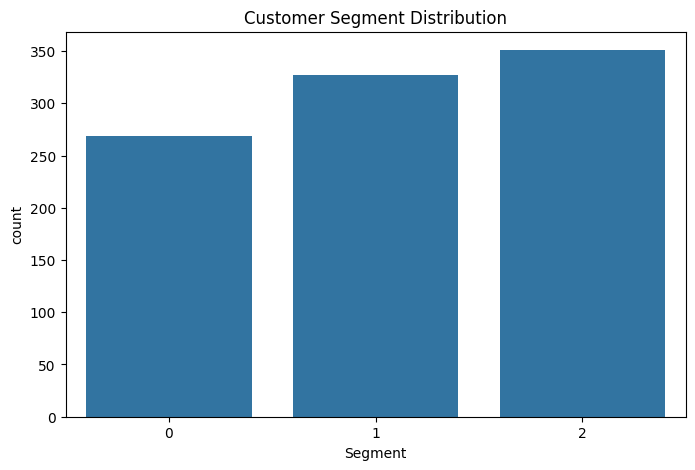

In [10]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='Segment',
    data=customer_df
)

plt.title("Customer Segment Distribution")

plt.show()

In [11]:
customer_df.groupby('Segment')[['Total_Sales','Quantity','Age']].mean()

,Total_Sales,Quantity,Age
Segment,,,
0,298056.366952,9.293680,42.150702
1,82736.333089,4.012232,53.643519
2,91645.287806,4.623932,29.157434


In [12]:
segment_mapping = {
    0: 'High Value',
    1: 'Low Value',
    2: 'Medium Value'
}

customer_df['Customer_Segment'] = customer_df['Segment'].map(segment_mapping)

customer_df.head()

,Customer_ID,Total_Sales,Quantity,Age,Segment,Customer_Segment
0,CUST1004,8321.54,2,64.0,1,Low Value
1,CUST1017,264230.68,7,42.0,0,High Value
2,CUST1026,164965.29,7,65.0,1,Low Value
3,CUST1032,146990.90,7,22.0,2,Medium Value
4,CUST1038,37068.40,5,32.0,2,Medium Value


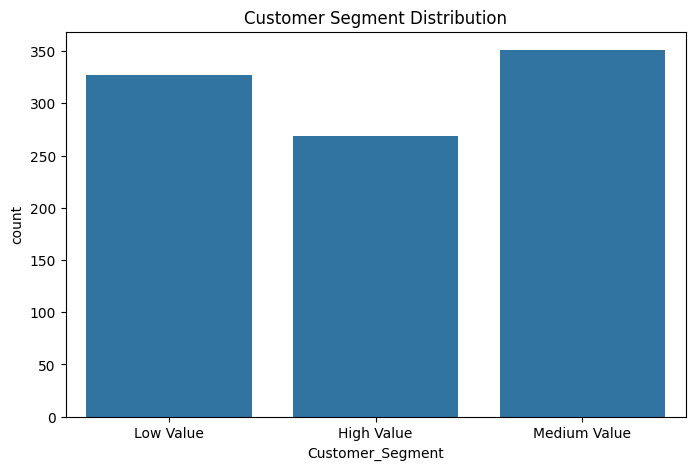

In [13]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='Customer_Segment',
    data=customer_df
)

plt.title("Customer Segment Distribution")

plt.show()

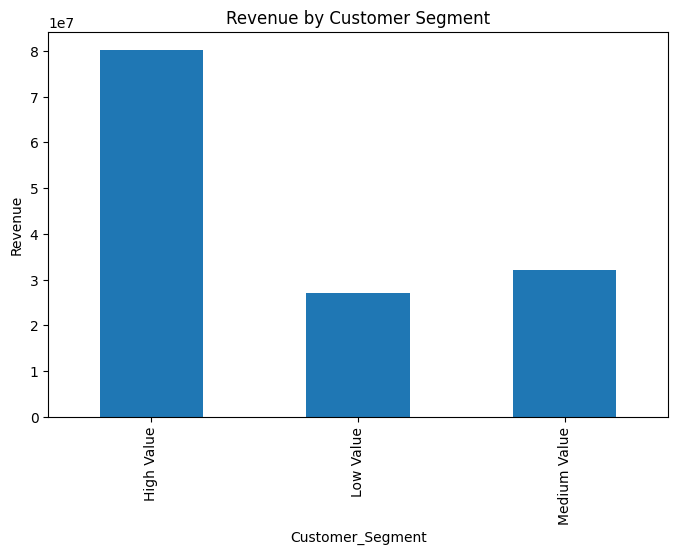

In [14]:
segment_sales = customer_df.groupby(
    'Customer_Segment'
)['Total_Sales'].sum()

plt.figure(figsize=(8,5))

segment_sales.plot(kind='bar')

plt.title("Revenue by Customer Segment")

plt.ylabel("Revenue")

plt.show()

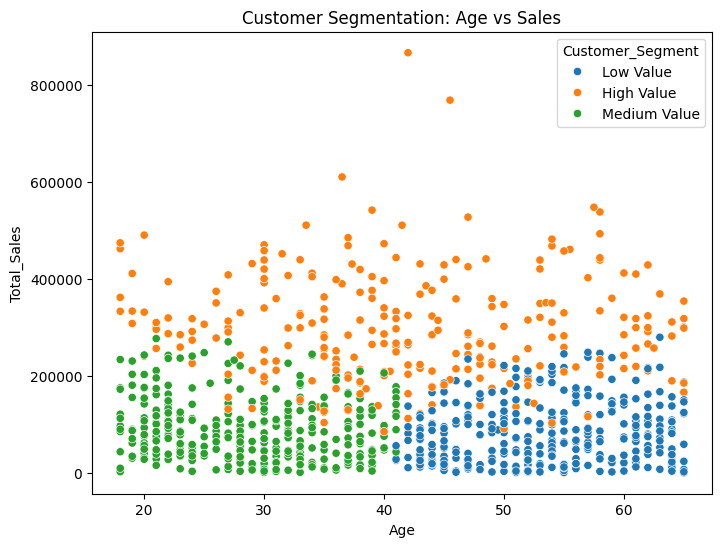

In [15]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=customer_df,
    x='Age',
    y='Total_Sales',
    hue='Customer_Segment'
)

plt.title("Customer Segmentation: Age vs Sales")

plt.show()

In [16]:
customer_df.to_csv(
    '../dashboard/customer_segments.csv',
    index=False
)

print("Customer Segments File Saved Successfully")

Customer Segments File Saved Successfully
